In [39]:
#imports
import matplotlib.pyplot as plt
import pandas as pd

In [40]:
""" # The code below was used to import the TLE data from the API and turn it into a CSV file. If you wish to use the most recent data from the API,
# feel free to create an account on space-track.org and imput your email and password into this code. Otherwise, please use the provided 
# allSatellites.csv file. This code is commented out as it will not work without valid credentials.

#using spacetrack library for easy importing and parsing
import json
import pandas as pd
from spacetrack import SpaceTrackClient
import spacetrack.operators as op

st = SpaceTrackClient(identity='address@fordham.edu', password='XXXXXXXXXXXXX')

# Fetch the data
allSat_raw = st.gp(format='json')

try:
    # Attempt to parse the data
    data_list = json.loads(allSat_raw)
    df = pd.DataFrame(data_list)
    
    # Check if we actually got data
    if not df.empty:
        print("Success! Top 5 Owners:")
        print(df['COUNTRY_CODE'].value_counts().head())
        df.to_csv("allSatellites.csv", index=False)
    else:
        print("Query successful, but no satellites found in that range.")

except json.JSONDecodeError:
    # If the API returned a text error message instead of JSON data
    print("API Error or Rate Limit Hit. The server said:")
    print(allSat_raw) """

' # The code below was used to import the TLE data from the API and turn it into a CSV file. If you wish to use the most recent data from the API,\n# feel free to create an account on space-track.org and imput your email and password into this code. Otherwise, please use the provided \n# allSatellites.csv file. This code is commented out as it will not work without valid credentials.\n\n#using spacetrack library for easy importing and parsing\nimport json\nimport pandas as pd\nfrom spacetrack import SpaceTrackClient\nimport spacetrack.operators as op\n\nst = SpaceTrackClient(identity=\'address@fordham.edu\', password=\'XXXXXXXXXXXXX\')\n\n# Fetch the data\nallSat_raw = st.gp(format=\'json\')\n\ntry:\n    # Attempt to parse the data\n    data_list = json.loads(allSat_raw)\n    df = pd.DataFrame(data_list)\n    \n    # Check if we actually got data\n    if not df.empty:\n        print("Success! Top 5 Owners:")\n        print(df[\'COUNTRY_CODE\'].value_counts().head())\n        df.to_csv(

In [41]:
# Load the whole dataset
df = pd.read_csv('CSV Data Sources/allSatellites.csv')
df.head()

,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,ORIGINATOR,OBJECT_NAME,OBJECT_ID,CENTER_NAME,REF_FRAME,TIME_SYSTEM,MEAN_ELEMENT_THEORY,...,RCS_SIZE,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2
0,3.0,GENERATED VIA SPACE-TRACK.ORG API,2004-08-15T23:45:29,18 SPCS,TITAN 3C TRANSTAGE DEB,1965-082TN,EARTH,TEME,UTC,SGP4,...,SMALL,US,1965-10-15,AFETR,1979-10-14,34108,11057914,0 TITAN 3C TRANSTAGE DEB,1 05711U 65082 TN 79287.16192894 .00054566 +0...,2 05711 032.0613 244.4288 0027646 258.3469 101...
1,3.0,GENERATED VIA SPACE-TRACK.ORG API,2004-08-15T23:39:56,18 SPCS,MOLNIYA 1-19,1971-115A,EARTH,TEME,UTC,SGP4,...,LARGE,CIS,1971-12-19,PKMTR,1977-04-13,33997,9964542,0 MOLNIYA 1-19,1 05712U 71115 A 77093.90117618 .23787954 +0...,2 05712 064.7888 135.1606 5926889 237.9001 051...
2,3.0,GENERATED VIA SPACE-TRACK.ORG API,2004-08-15T23:39:56,18 SPCS,SL-6 R/B(2),1971-115B,EARTH,TEME,UTC,SGP4,...,LARGE,CIS,1971-12-19,PKMTR,1977-09-22,33997,9964601,0 SL-6 R/B(2),1 05713U 71115 B 77255.43254682 .06295839 +0...,2 05713 064.7296 348.3468 2167024 220.8230 120...
3,3.0,GENERATED VIA SPACE-TRACK.ORG API,2004-08-17T15:26:48,18 SPCS,COSMOS 249 DEB,1968-091CB,EARTH,TEME,UTC,SGP4,...,SMALL,CIS,1968-10-20,TTMTR,2000-04-06,35585,33106730,0 COSMOS 249 DEB,1 05714U 68091CB 00096.92693632 .18433670 8...,2 05714 062.2722 314.6495 0016255 239.9054 126...
4,3.0,GENERATED VIA SPACE-TRACK.ORG API,2026-04-26T18:02:45,18 SPCS,THOR ABLESTAR DEB,1961-015JS,EARTH,TEME,UTC,SGP4,...,SMALL,US,1961-06-29,AFETR,NaN,5152756,320957396,0 THOR ABLESTAR DEB,1 05715U 61015JS 26116.29498631 -.00000112 0...,2 05715 66.5636 219.8215 0148954 91.9250 301...


In [42]:
# Understand the dataset size and categories:
print(f'Unique Satelite Categories are: {df["OBJECT_TYPE"].unique()} \n')
print(f'The distribution of objects by categories are as follows: \n {df["OBJECT_TYPE"].value_counts()}')

print(f'\n There are these {len(df.columns)} columns:')
df.columns

Unique Satelite Categories are: ['DEBRIS' 'PAYLOAD' 'ROCKET BODY' 'UNKNOWN' 'TBA'] 

The distribution of objects by categories are as follows: 
 OBJECT_TYPE
DEBRIS         34370
PAYLOAD        24160
ROCKET BODY     6525
UNKNOWN         2134
TBA              202
Name: count, dtype: int64

 There are these 40 columns:


Index(['CCSDS_OMM_VERS', 'COMMENT', 'CREATION_DATE', 'ORIGINATOR',
       'OBJECT_NAME', 'OBJECT_ID', 'CENTER_NAME', 'REF_FRAME', 'TIME_SYSTEM',
       'MEAN_ELEMENT_THEORY', 'EPOCH', 'MEAN_MOTION', 'ECCENTRICITY',
       'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER', 'MEAN_ANOMALY',
       'EPHEMERIS_TYPE', 'CLASSIFICATION_TYPE', 'NORAD_CAT_ID',
       'ELEMENT_SET_NO', 'REV_AT_EPOCH', 'BSTAR', 'MEAN_MOTION_DOT',
       'MEAN_MOTION_DDOT', 'SEMIMAJOR_AXIS', 'PERIOD', 'APOAPSIS', 'PERIAPSIS',
       'OBJECT_TYPE', 'RCS_SIZE', 'COUNTRY_CODE', 'LAUNCH_DATE', 'SITE',
       'DECAY_DATE', 'FILE', 'GP_ID', 'TLE_LINE0', 'TLE_LINE1', 'TLE_LINE2'],
      dtype='object')

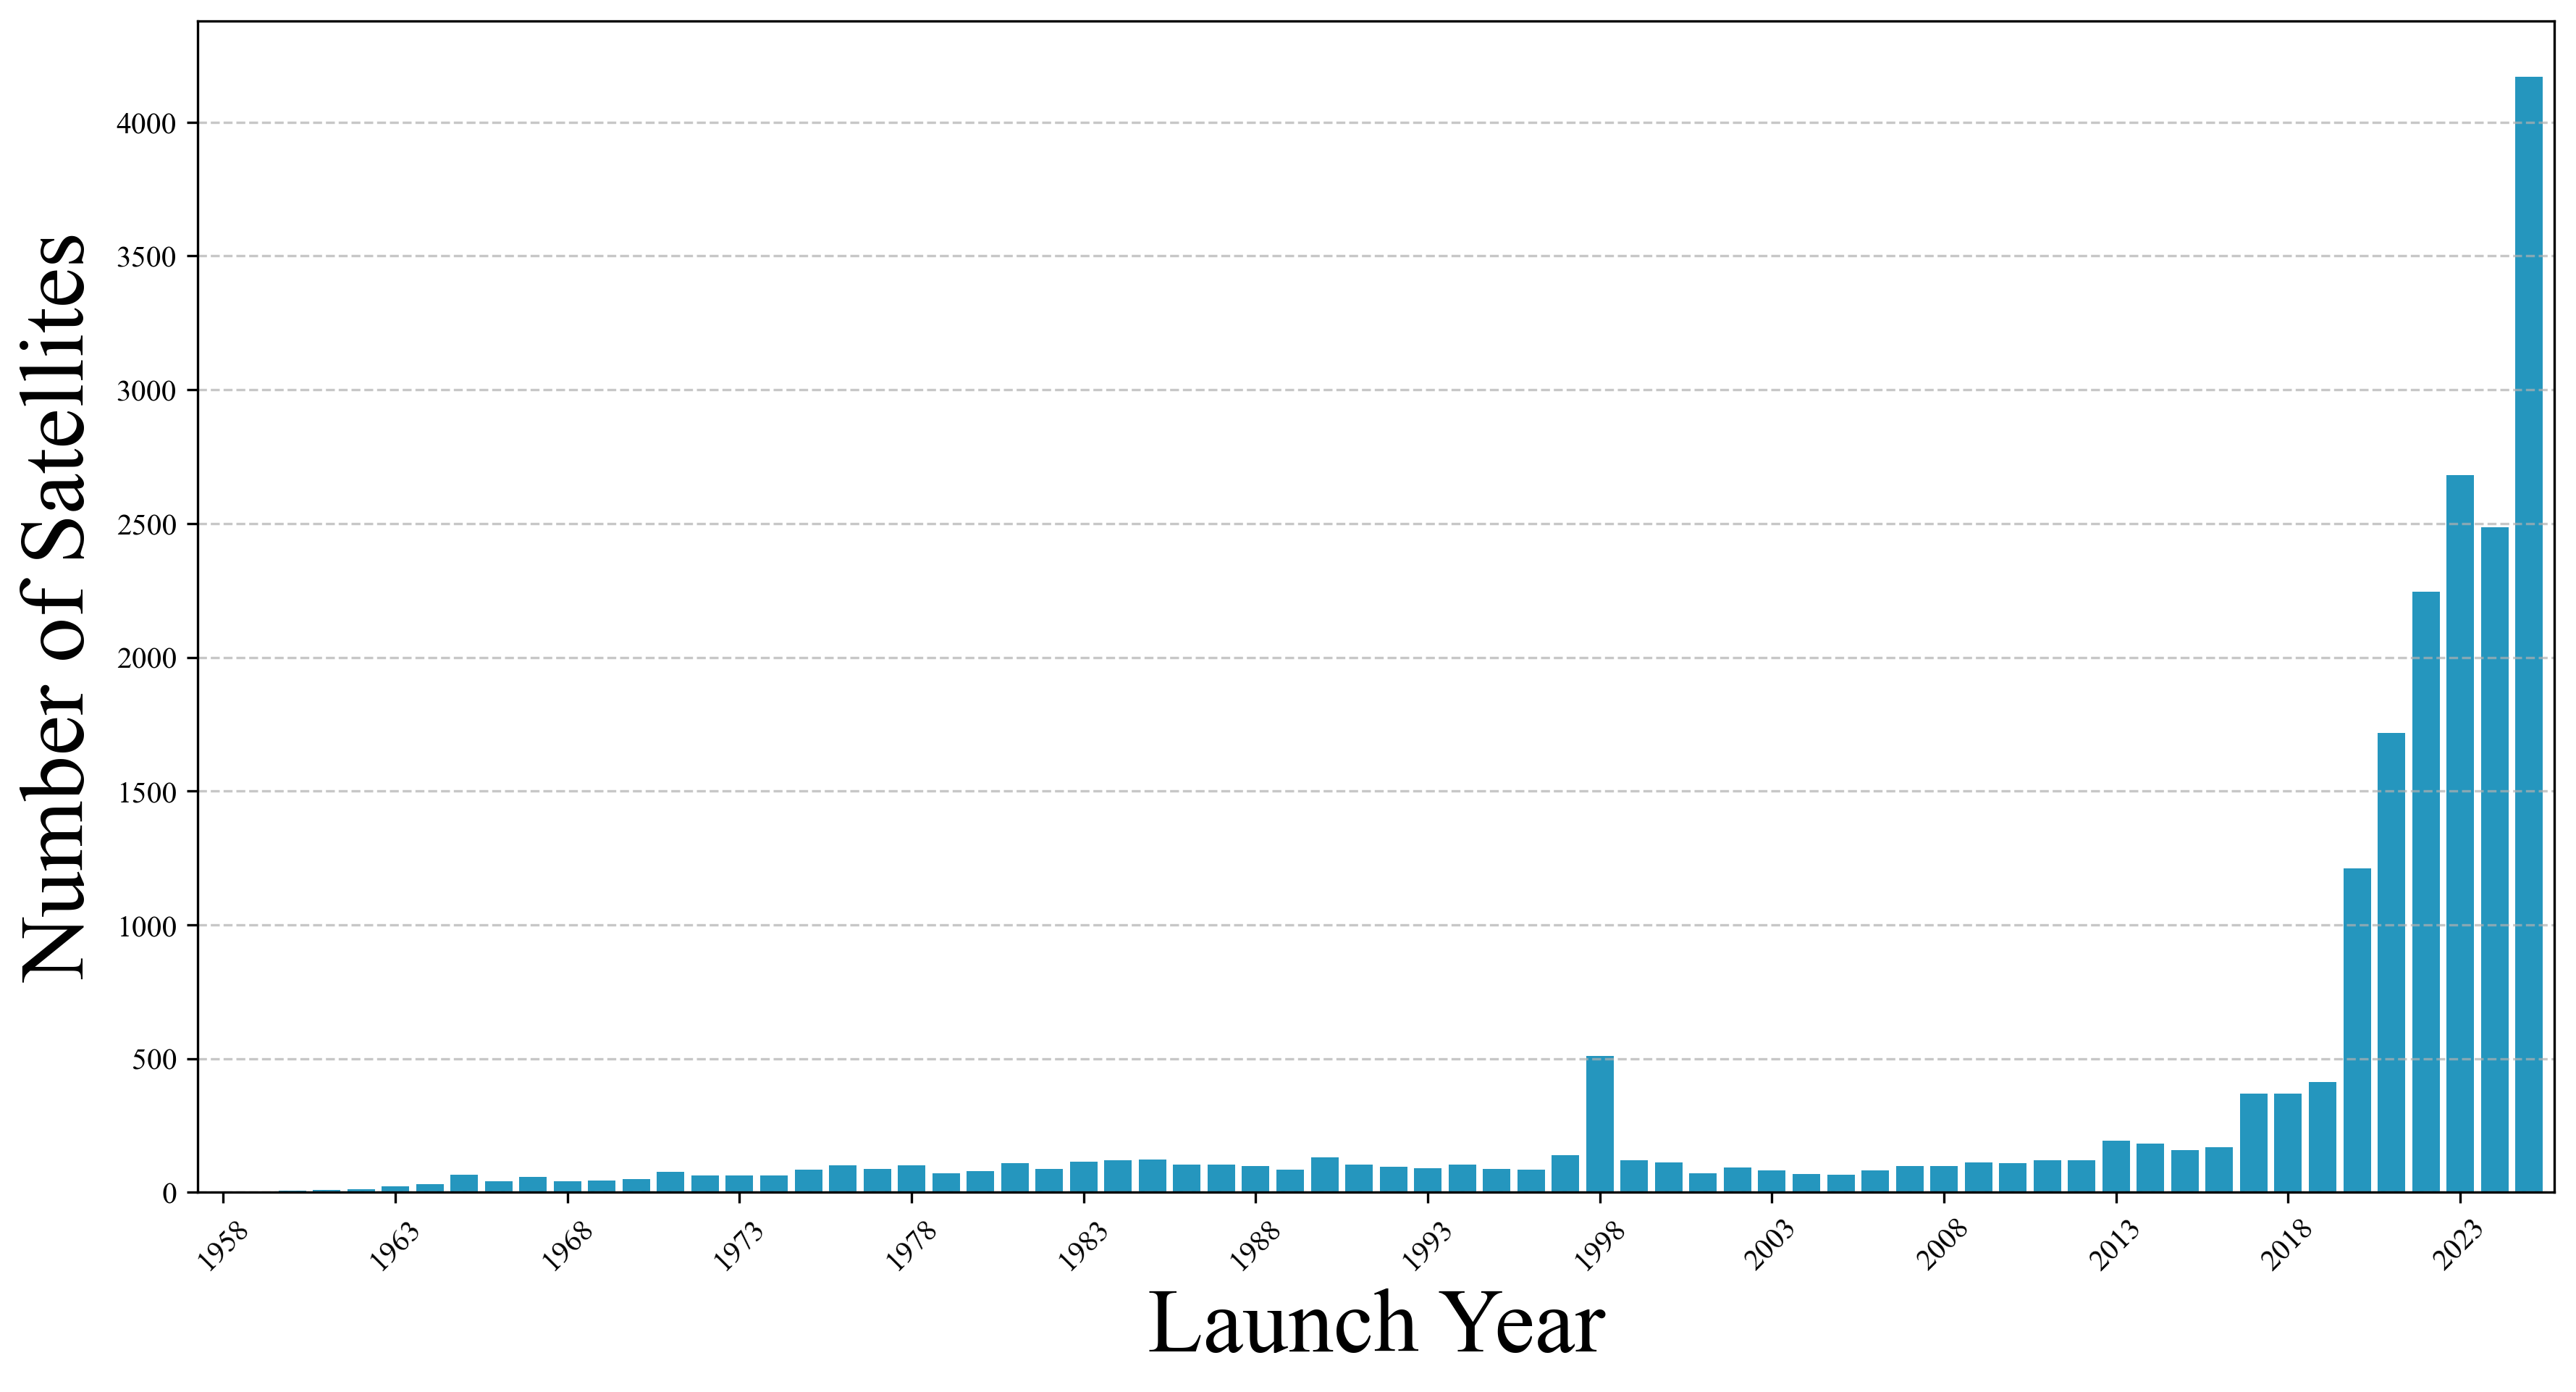

In [43]:
# Interested in the rate of launch year by year
allSat = df[df['OBJECT_TYPE'] == 'PAYLOAD']
allSat = allSat.dropna(subset='LAUNCH_DATE')
allSat['LAUNCH_DATE'] = pd.to_datetime(allSat['LAUNCH_DATE']) # Make the LAUNCH_DATE into and actual date and time for analysis
allSat['LAUNCH_YEAR'] = allSat['LAUNCH_DATE'].dt.year.astype(int) # Create a column just with the launch years
allSat = allSat[allSat['LAUNCH_YEAR'] != 2026] # Omitting 2026 since the year has not finished yet
yearlyCount = allSat['LAUNCH_YEAR'].value_counts().sort_index()
years = yearlyCount.index

# Matplotlib bar graph
plt.figure(figsize=(14,7), dpi=300)
plt.bar(years, yearlyCount, color='#2596be')

# plt.title('Number of Satellite Launches by Year') #commented out for paper
plt.xlabel('Launch Year', fontsize = 30)
plt.margins(x=0.005)
plt.ylabel('Number of Satellites', fontsize = 30)
plt.xticks(
    years[::5],  # Take every 5th year value from the index so x axis is readable
    rotation=45
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [44]:
# Now want to look at specifically active satelites
activeSat = df[df['DECAY_DATE'].isna()].copy()
print(f'Unique Satelite Categories are: {activeSat["OBJECT_TYPE"].unique()} \n')
print(activeSat['OBJECT_TYPE'].value_counts())
activeSat.head()

Unique Satelite Categories are: ['DEBRIS' 'PAYLOAD' 'ROCKET BODY' 'UNKNOWN' 'TBA'] 

OBJECT_TYPE
PAYLOAD        17427
DEBRIS         12314
ROCKET BODY     2229
UNKNOWN         1722
TBA              183
Name: count, dtype: int64


,CCSDS_OMM_VERS,COMMENT,CREATION_DATE,ORIGINATOR,OBJECT_NAME,OBJECT_ID,CENTER_NAME,REF_FRAME,TIME_SYSTEM,MEAN_ELEMENT_THEORY,...,RCS_SIZE,COUNTRY_CODE,LAUNCH_DATE,SITE,DECAY_DATE,FILE,GP_ID,TLE_LINE0,TLE_LINE1,TLE_LINE2
4,3.0,GENERATED VIA SPACE-TRACK.ORG API,2026-04-26T18:02:45,18 SPCS,THOR ABLESTAR DEB,1961-015JS,EARTH,TEME,UTC,SGP4,...,SMALL,US,1961-06-29,AFETR,NaN,5152756,320957396,0 THOR ABLESTAR DEB,1 05715U 61015JS 26116.29498631 -.00000112 0...,2 05715 66.5636 219.8215 0148954 91.9250 301...
5,3.0,GENERATED VIA SPACE-TRACK.ORG API,2026-04-27T10:24:28,18 SPCS,THOR ABLESTAR DEB,1961-015JT,EARTH,TEME,UTC,SGP4,...,SMALL,US,1961-06-29,AFETR,NaN,5154452,321064320,0 THOR ABLESTAR DEB,1 05716U 61015JT 26117.16791638 .00003565 0...,2 05716 66.6971 33.6612 0061090 52.7936 307...
8,3.0,GENERATED VIA SPACE-TRACK.ORG API,2026-04-27T15:46:33,18 SPCS,COSMOS 397 DEB *,1971-015CB,EARTH,TEME,UTC,SGP4,...,SMALL,CIS,1971-02-25,TTMTR,NaN,5154579,321098763,0 COSMOS 397 DEB *,1 5720U 71015CB 26117.46036416 .00000017 0...,2 5720 66.7292 23.1863 0103902 358.4823 1...
9,3.0,GENERATED VIA SPACE-TRACK.ORG API,2026-04-27T15:46:33,18 SPCS,COSMOS 469,1971-117A,EARTH,TEME,UTC,SGP4,...,LARGE,CIS,1971-12-25,TTMTR,NaN,5154579,321098264,0 COSMOS 469,1 5721U 71117A 26117.39121444 -.00000047 0...,2 5721 64.4853 120.7061 0066376 278.2210 81...
16,3.0,GENERATED VIA SPACE-TRACK.ORG API,2026-04-27T15:46:33,18 SPCS,AUREOLE 1,1971-119A,EARTH,TEME,UTC,SGP4,...,LARGE,FR,1971-12-27,PKMTR,NaN,5154579,321098764,0 AUREOLE 1,1 5729U 71119A 26117.45234229 .00003491 0...,2 5729 73.9488 176.9322 0706947 29.3333 334...


### General Information about classifying satellite orbits by their period
| Orbit               | Period      | Typical Use                         |
|---------------------|-------------|-------------------------------------|
| LEO (Low Earth)     | 84 – 128    | Starlink, ISS, Earth Imaging        |
| MEO (Medium Earth)  | 128 – 1,436 | GPS, Galileo, Navigation            |
| GEO (Geostationary) | ≈ 1,436     | TV, Weather, High-Orbit Comms       |
| HEO (High Earth)    | > 1,440     | Deep Space Probes, High-dwell Comms |

In [45]:
# Assigning satellites' orbit types by their period
LEO = activeSat[activeSat['PERIOD'].between(84,128)]
MEO = activeSat[activeSat['PERIOD'].between(128, 1429)]
GEO = activeSat[activeSat['PERIOD'].between(1430, 1440)]
HEO = activeSat[activeSat['PERIOD'] > 1440]

In [46]:
# Want to get a general idea of the data
debris = activeSat.loc[activeSat['OBJECT_TYPE'] == 'DEBRIS']
LEOsat = LEO.loc[LEO['OBJECT_TYPE'] == 'PAYLOAD']
MEOsat = MEO.loc[MEO['OBJECT_TYPE'] == 'PAYLOAD']
GEOsat = GEO.loc[GEO['OBJECT_TYPE'] == 'PAYLOAD']
HEOSat = HEO.loc[HEO['OBJECT_TYPE'] == 'PAYLOAD']
unknownSat = activeSat[activeSat['OBJECT_TYPE'].isin(['UNKNOWN', 'TBA'])]
totalNum = len(activeSat)

print(f'There are {len(LEOsat)} LEO satelites, {len(MEOsat)} MEO satelites, {len(GEOsat)} GEO satelites, and {len(HEOSat)} HEO satelites, as well as {len(debris)} debris in Earth orbit')
print(f'Out of all bodies in orbit, {(len(debris)/totalNum*100):.1f}% are debris, {(len(LEOsat)/totalNum*100):.1f}% are LEO satelites, {(len(MEOsat)/totalNum*100):.1f}% are MEO satelites, {(len(GEOsat)/totalNum*100):.1f}% are GEO satelites, {(len(HEOSat)/totalNum*100):.1f}% are HEO satelites, and {(len(unknownSat)/totalNum*100):.1f}% are unknown.')


There are 15417 LEO satelites, 621 MEO satelites, 767 GEO satelites, and 620 HEO satelites, as well as 12314 debris in Earth orbit
Out of all bodies in orbit, 36.4% are debris, 45.5% are LEO satelites, 1.8% are MEO satelites, 2.3% are GEO satelites, 1.8% are HEO satelites, and 5.6% are unknown.


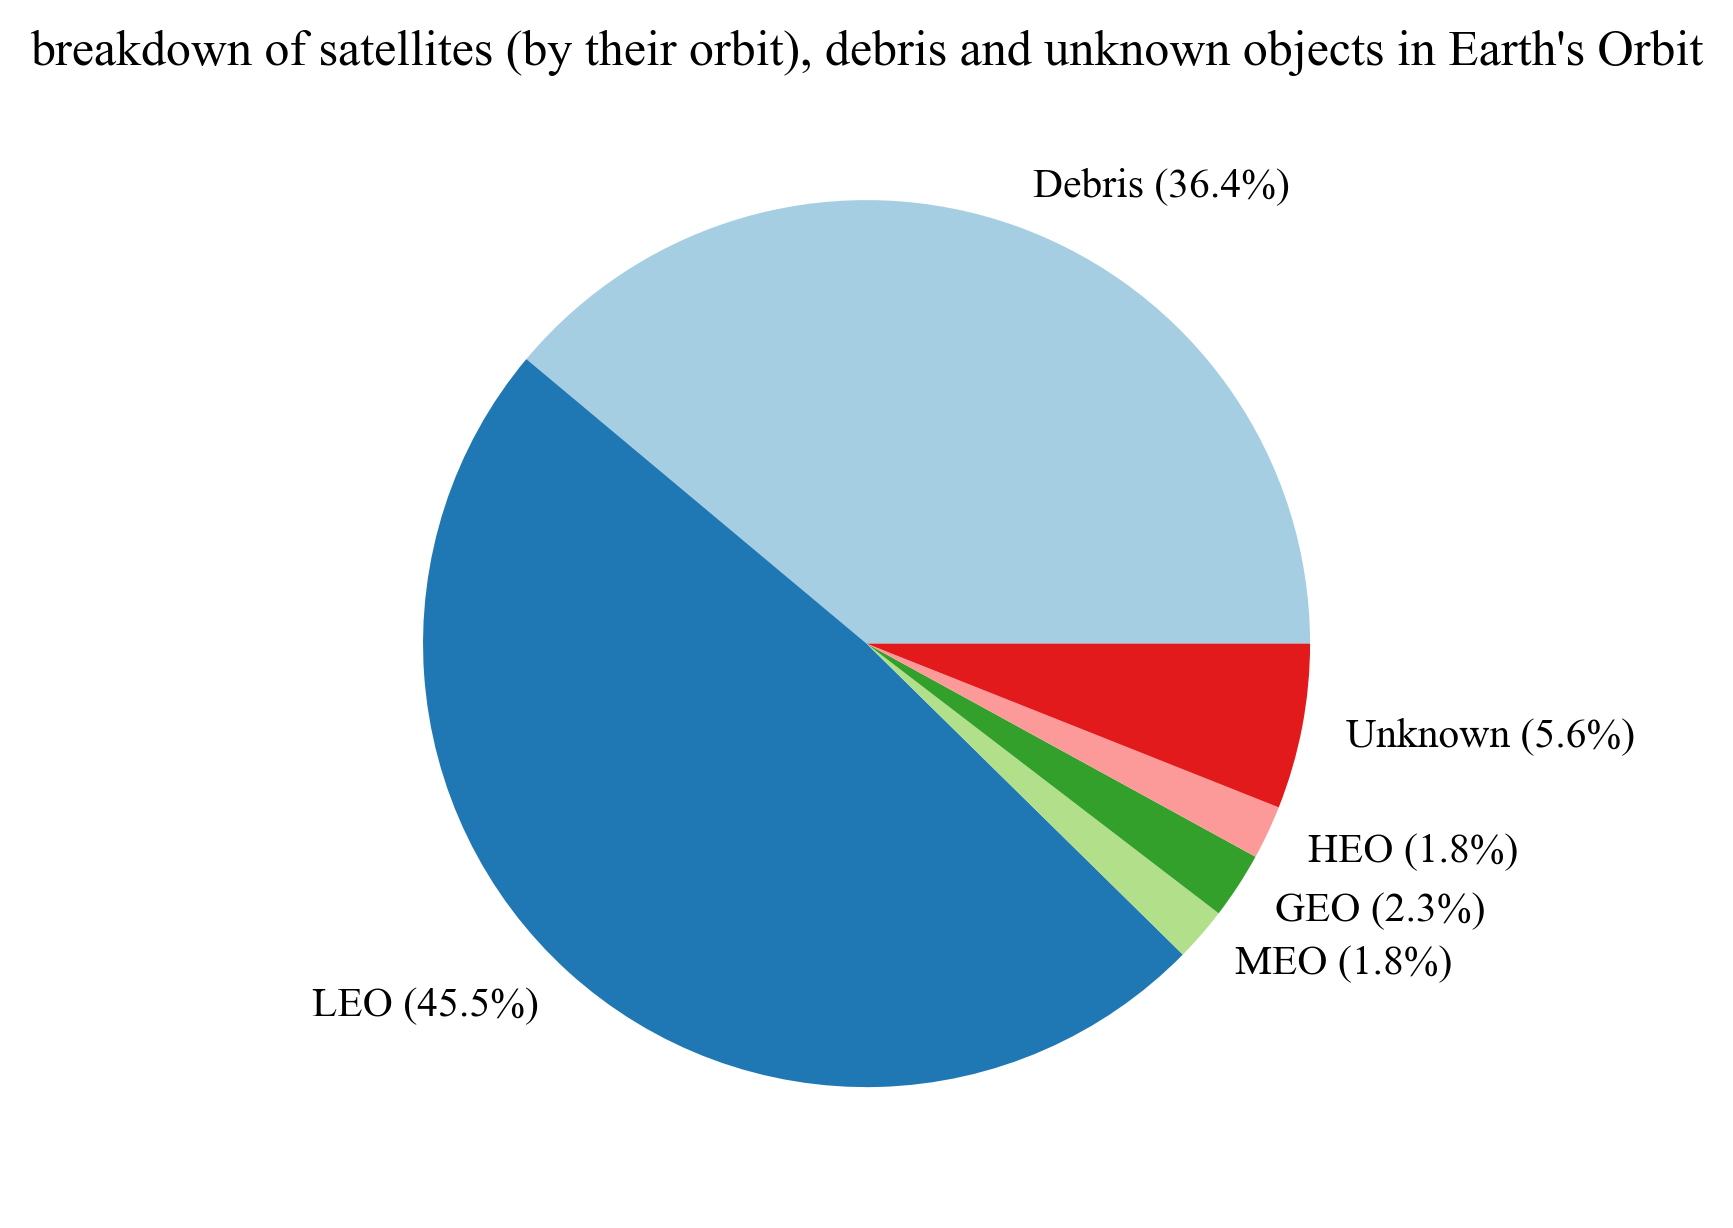

In [47]:
# They say a picture is worth a thousand words: Making the info above into a pie chart
plt.figure(dpi=300)
customColors = plt.get_cmap('Paired').colors[:6]

# Data labels and sizes
raw_labels = ['Debris', 'LEO', 'MEO', 'GEO', 'HEO', 'Unknown']
sizes = [
    len(debris)/totalNum*100, 
    len(LEOsat)/totalNum*100, 
    len(MEOsat)/totalNum*100, 
    len(GEOsat)/totalNum*100, 
    len(HEOSat)/totalNum*100, 
    len(unknownSat)/totalNum*100
]

# Format labels to include percentage points in parentheses
labels = [f"{label} ({size:.1f}%)" for label, size in zip(raw_labels, sizes)]

# Create the pie chart
plt.pie(sizes, labels=labels, colors=customColors)

# Display the chart 
plt.title("breakdown of satellites (by their orbit), debris and unknown objects in Earth's Orbit", loc='center')
plt.show()

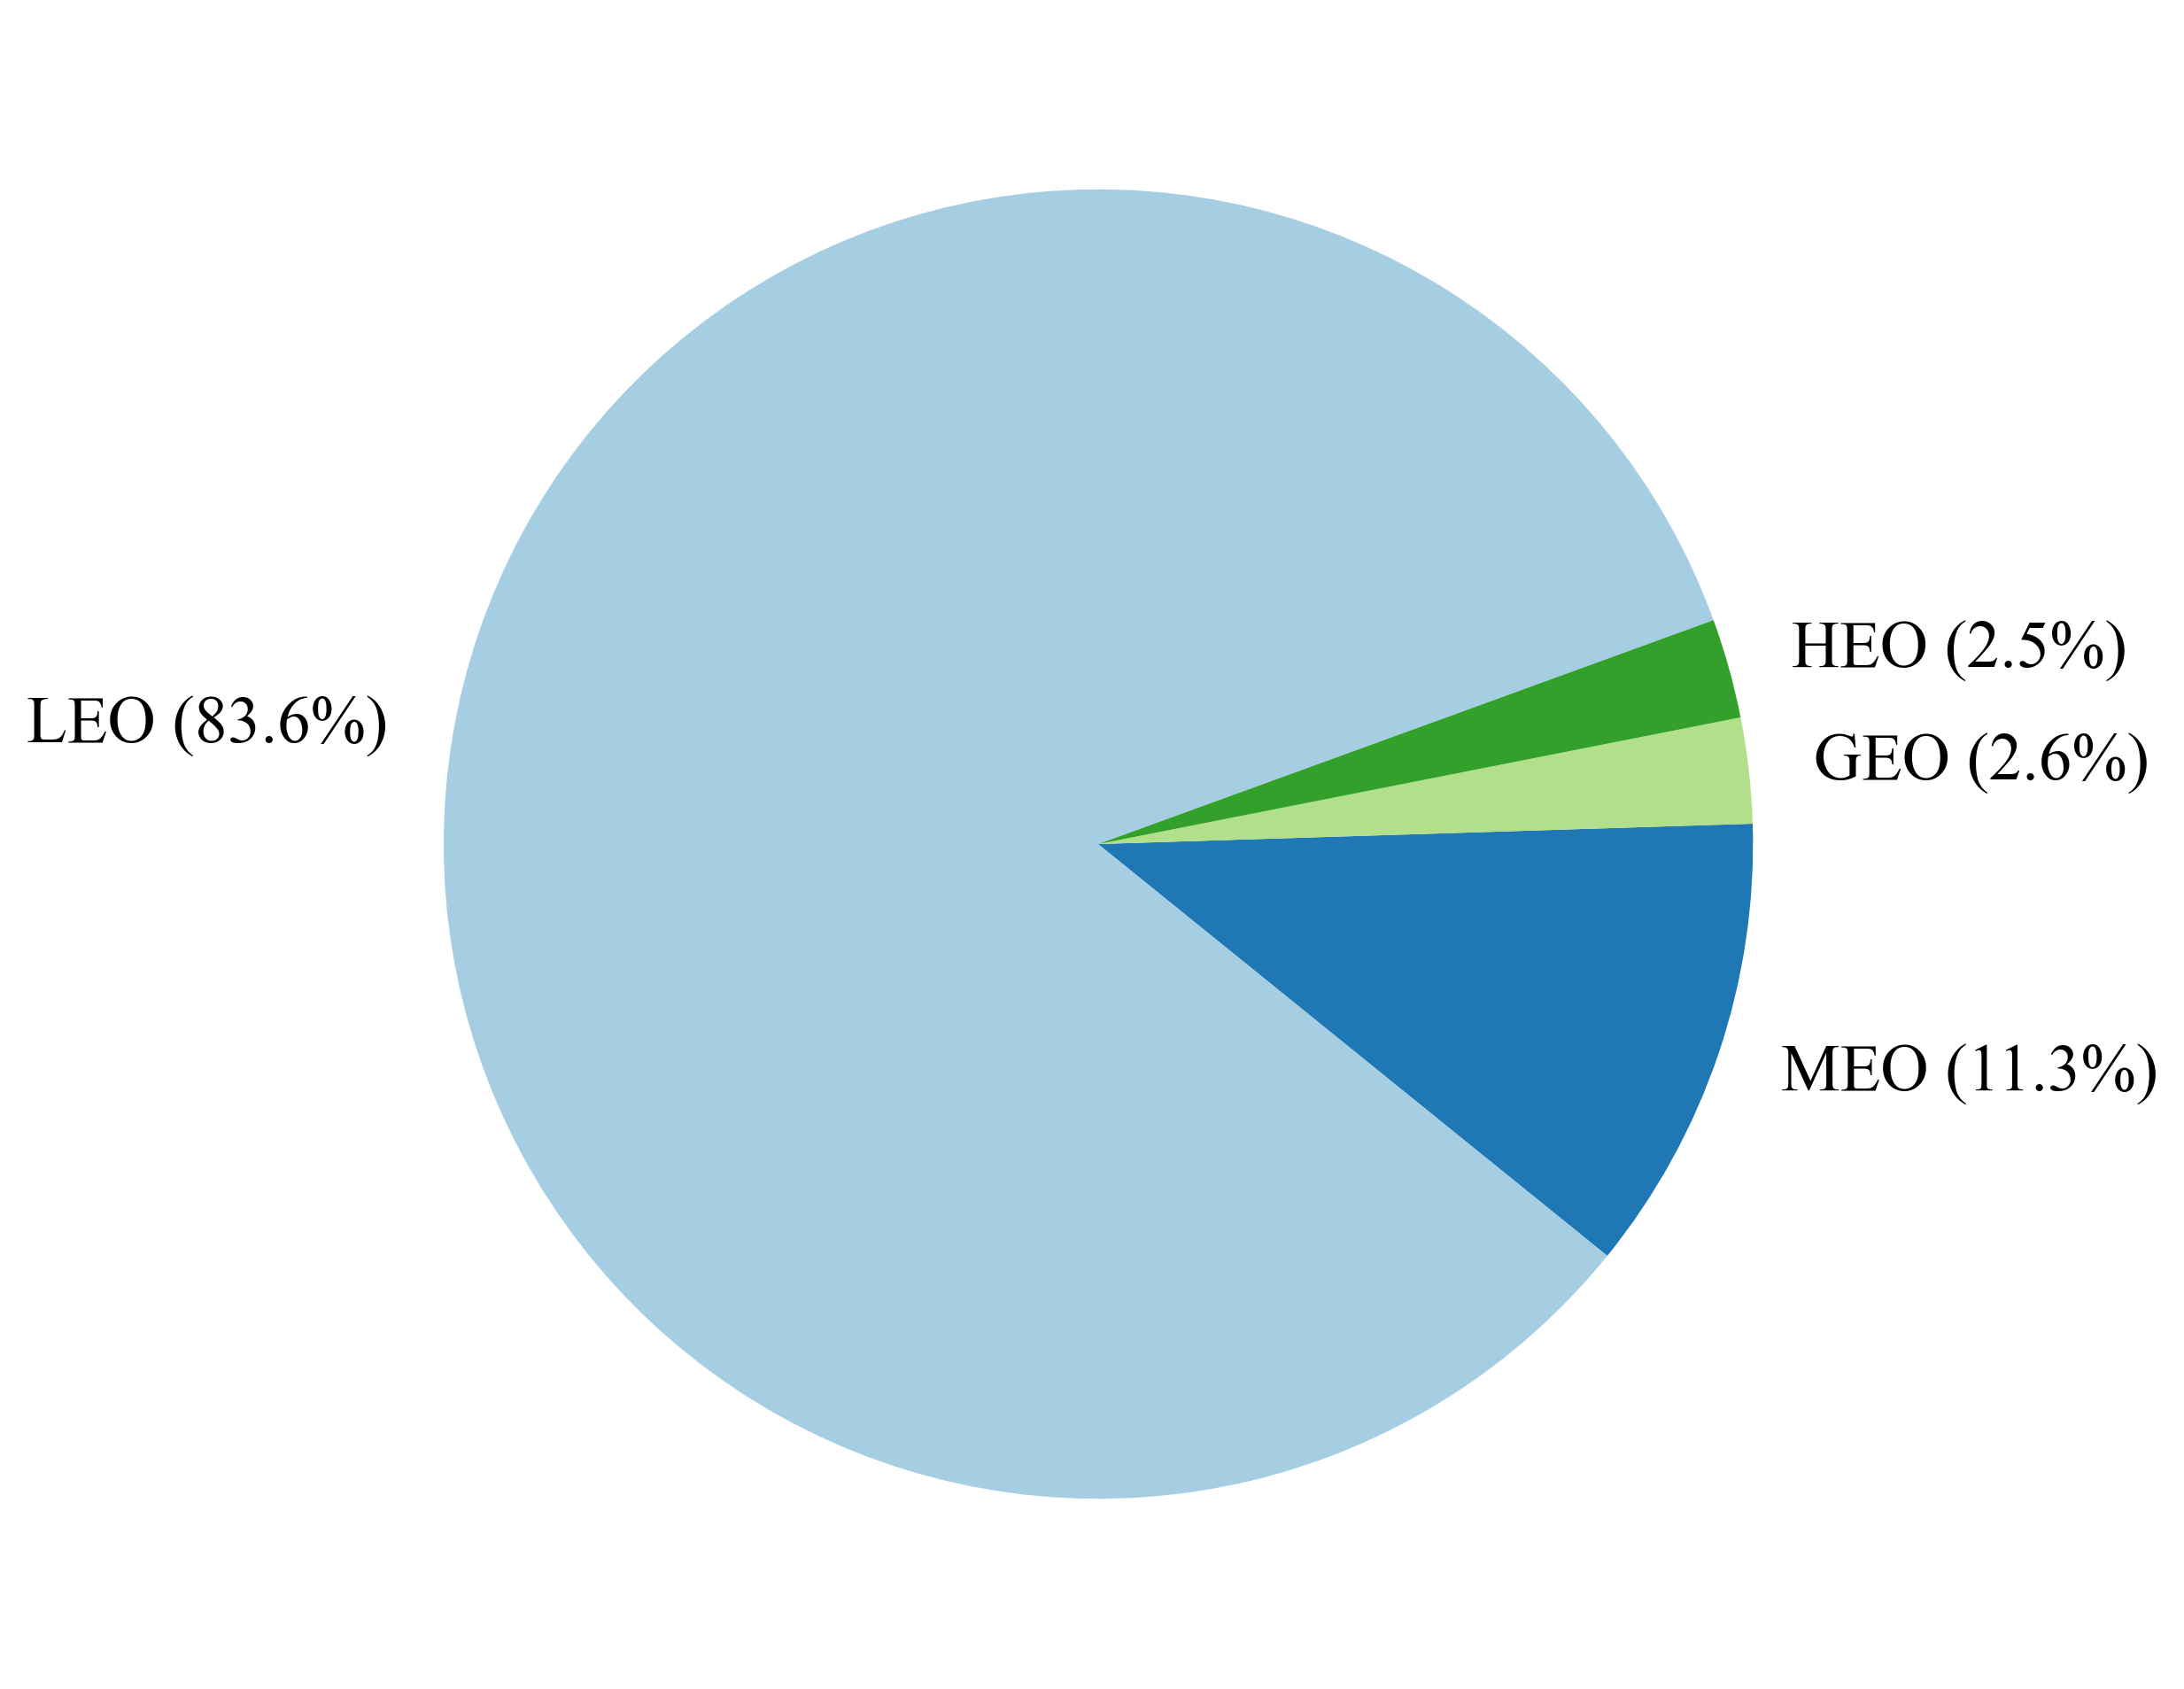

In [48]:
# Want to see breakdown by orbital altitudes
# PI chart
plt.figure(figsize=(8, 8), dpi=300) 
customColors = plt.get_cmap('Paired').colors[:6]

# Data labels and sizes
raw_labels = ['LEO', 'MEO', 'GEO', 'HEO']
sizes = [
    len(LEO)/totalNum*100, 
    len(MEO)/totalNum*100, 
    len(GEO)/totalNum*100, 
    len(HEO)/totalNum*100, 
]

# Format labels to include percentage points in parentheses
labels = [f"{label} ({size:.1f}%)" for label, size in zip(raw_labels, sizes)]

# Create the pie chart
plt.pie(sizes, labels=labels, colors=customColors, startangle=20, textprops={'fontsize': 18})

# Display the chart 
plt.show()

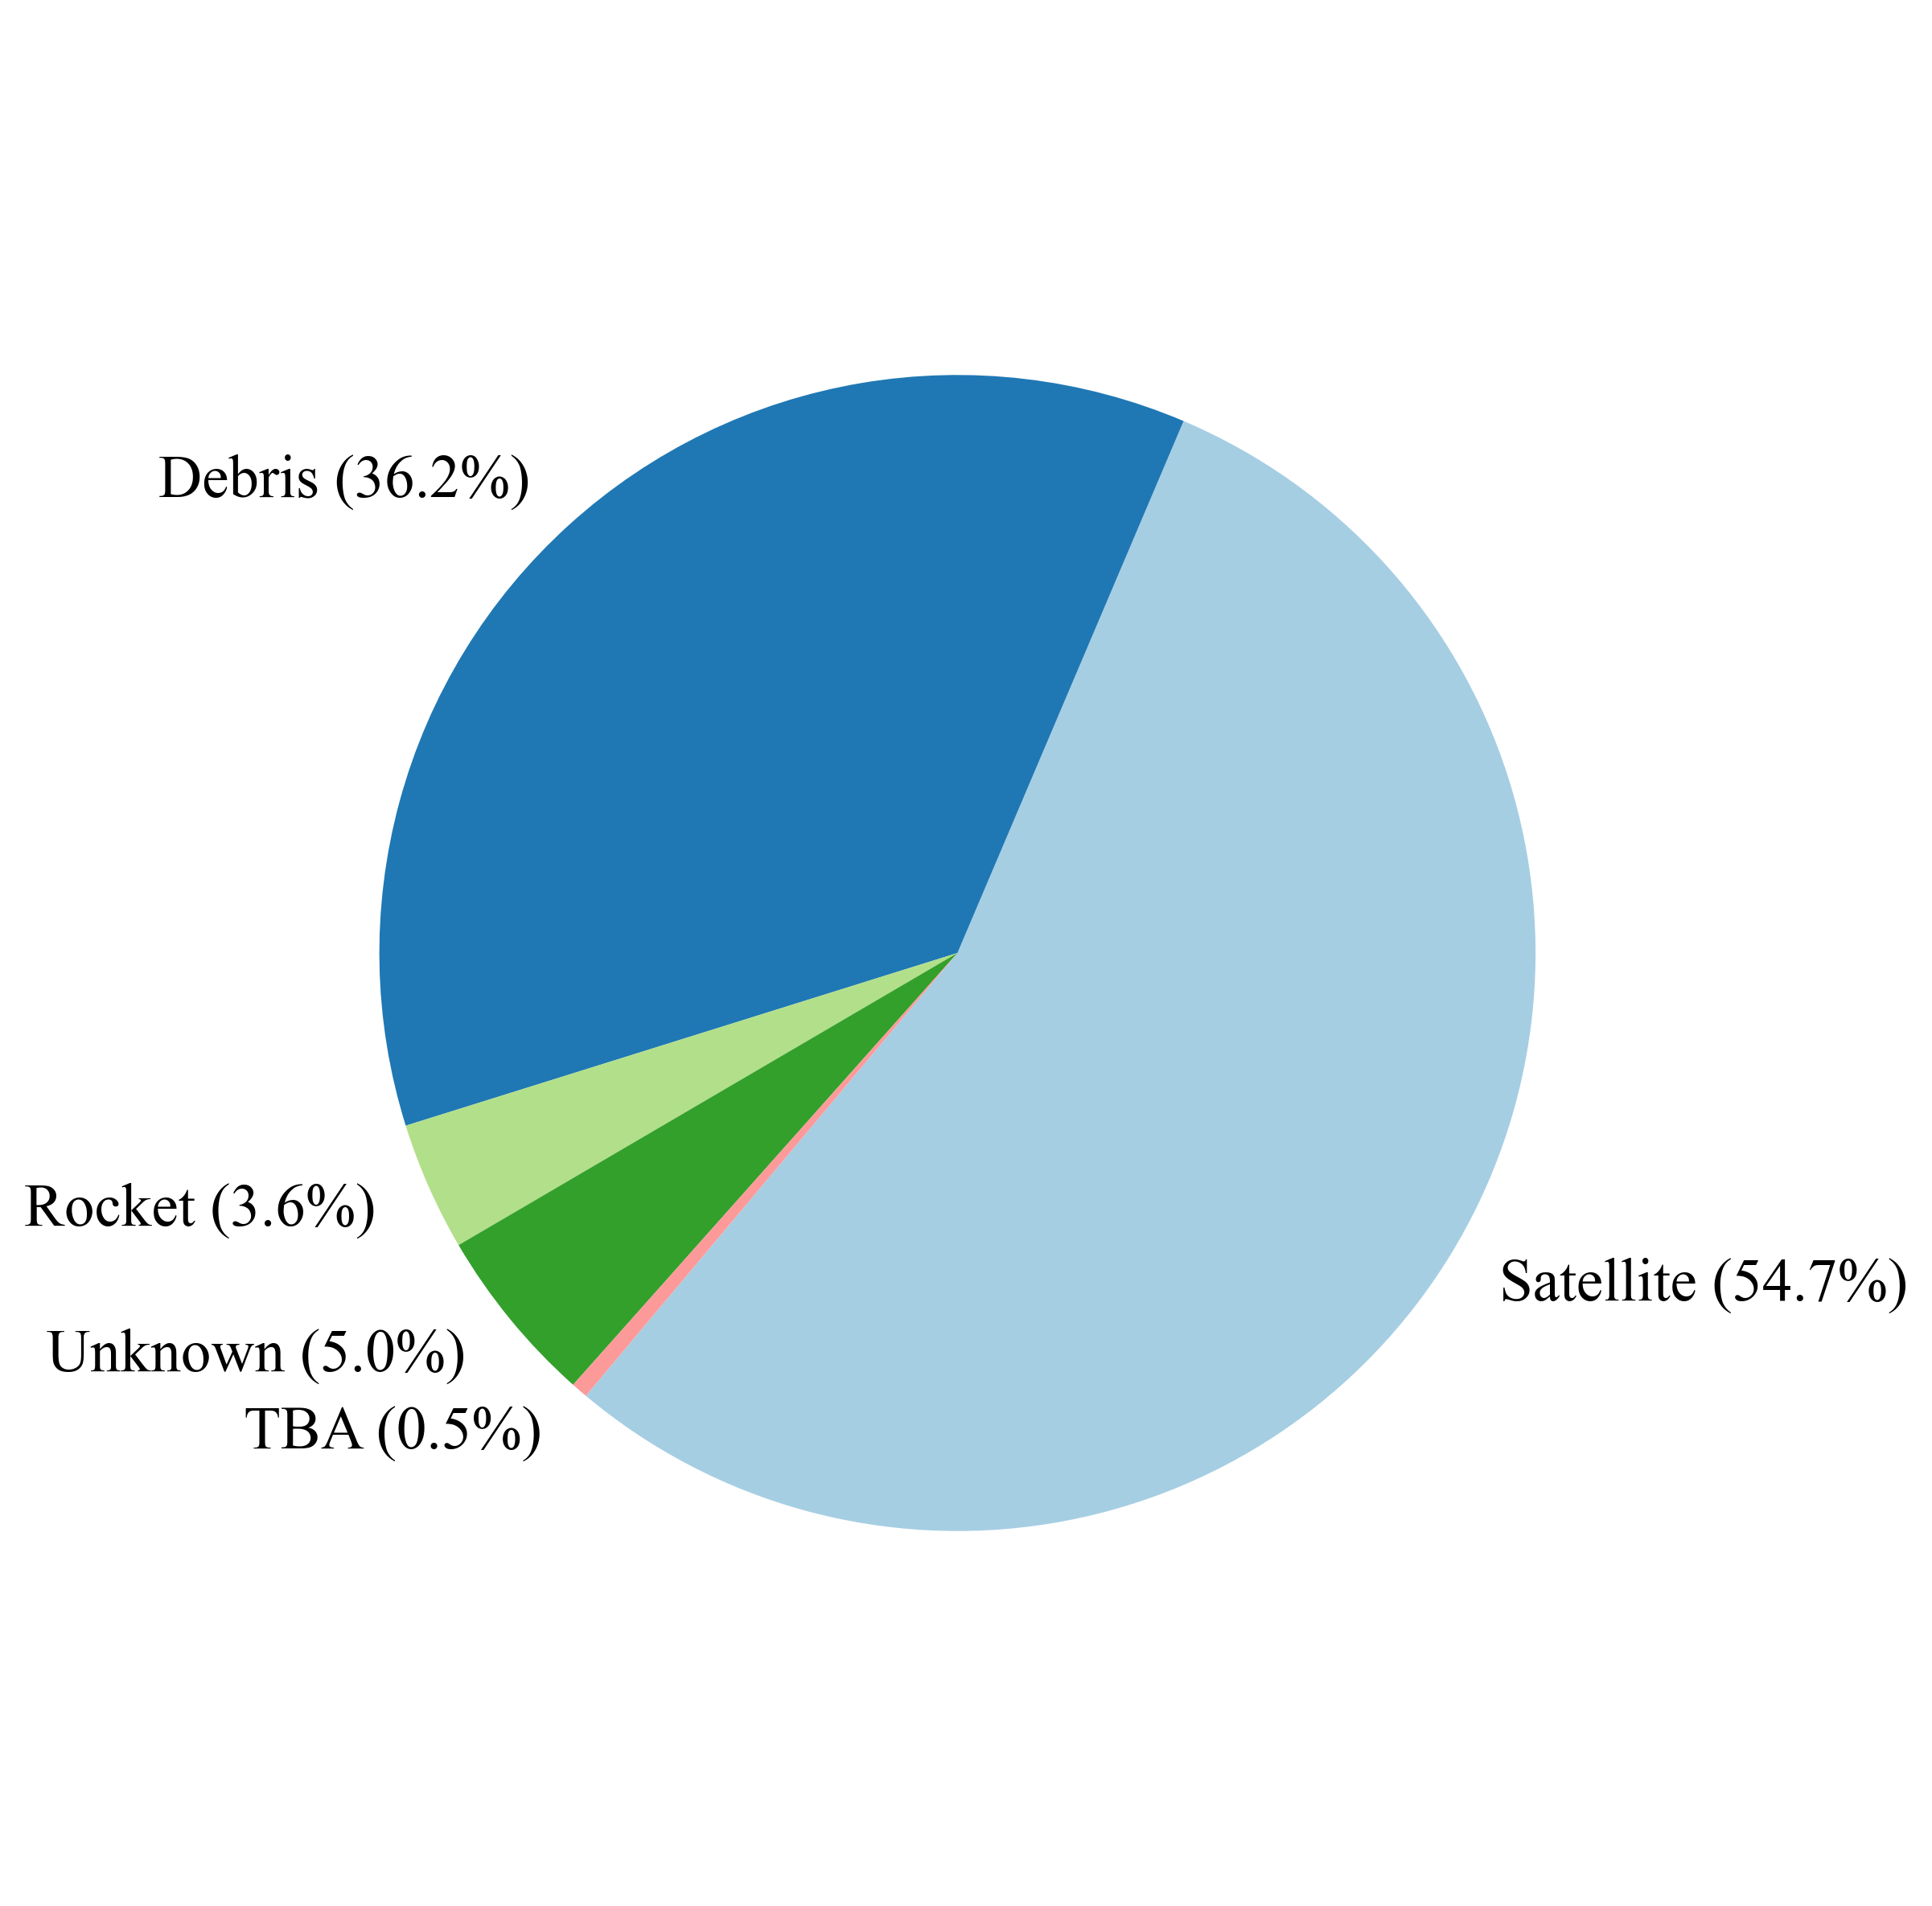

In [49]:
# Want to see the distribution of objects by category only in LEO specifically since that is what the random forest is trained on
df = pd.read_csv('CSV Data Sources/leoSatellites.csv')

# Chart Resolution
plt.figure(figsize=(8, 8), dpi=300) 
customColors = plt.get_cmap('Paired').colors[:6] # preferred color scheme

# Data labels and sizes 
totalNum = len(df)
raw_labels = ['Satellite', 'Debris', 'Rocket', 'Unknown', 'TBA']
sizes = [
    len(df[df['OBJECT_TYPE'] == 'PAYLOAD']) / totalNum * 100,
    len(df[df['OBJECT_TYPE'] == 'DEBRIS']) / totalNum * 100,
    len(df[df['OBJECT_TYPE'] == 'ROCKET BODY']) / totalNum * 100,
    len(df[df['OBJECT_TYPE'] == 'UNKNOWN']) / totalNum * 100,
    len(df[df['OBJECT_TYPE'] == 'TBA']) / totalNum * 100
]

# Format labels to include percentage points
labels = [f"{label} ({size:.1f}%)" for label, size in zip(raw_labels, sizes)]

# Create the pie chart
plt.pie(sizes, labels=labels, colors=customColors, startangle=230, textprops={'fontsize': 18})

plt.axis('equal') # Ensures pie is drawn as a circle and centered
plt.tight_layout() # Adjusts subplot params so labels don't push the pie off-center

# Display the chart 
plt.show()


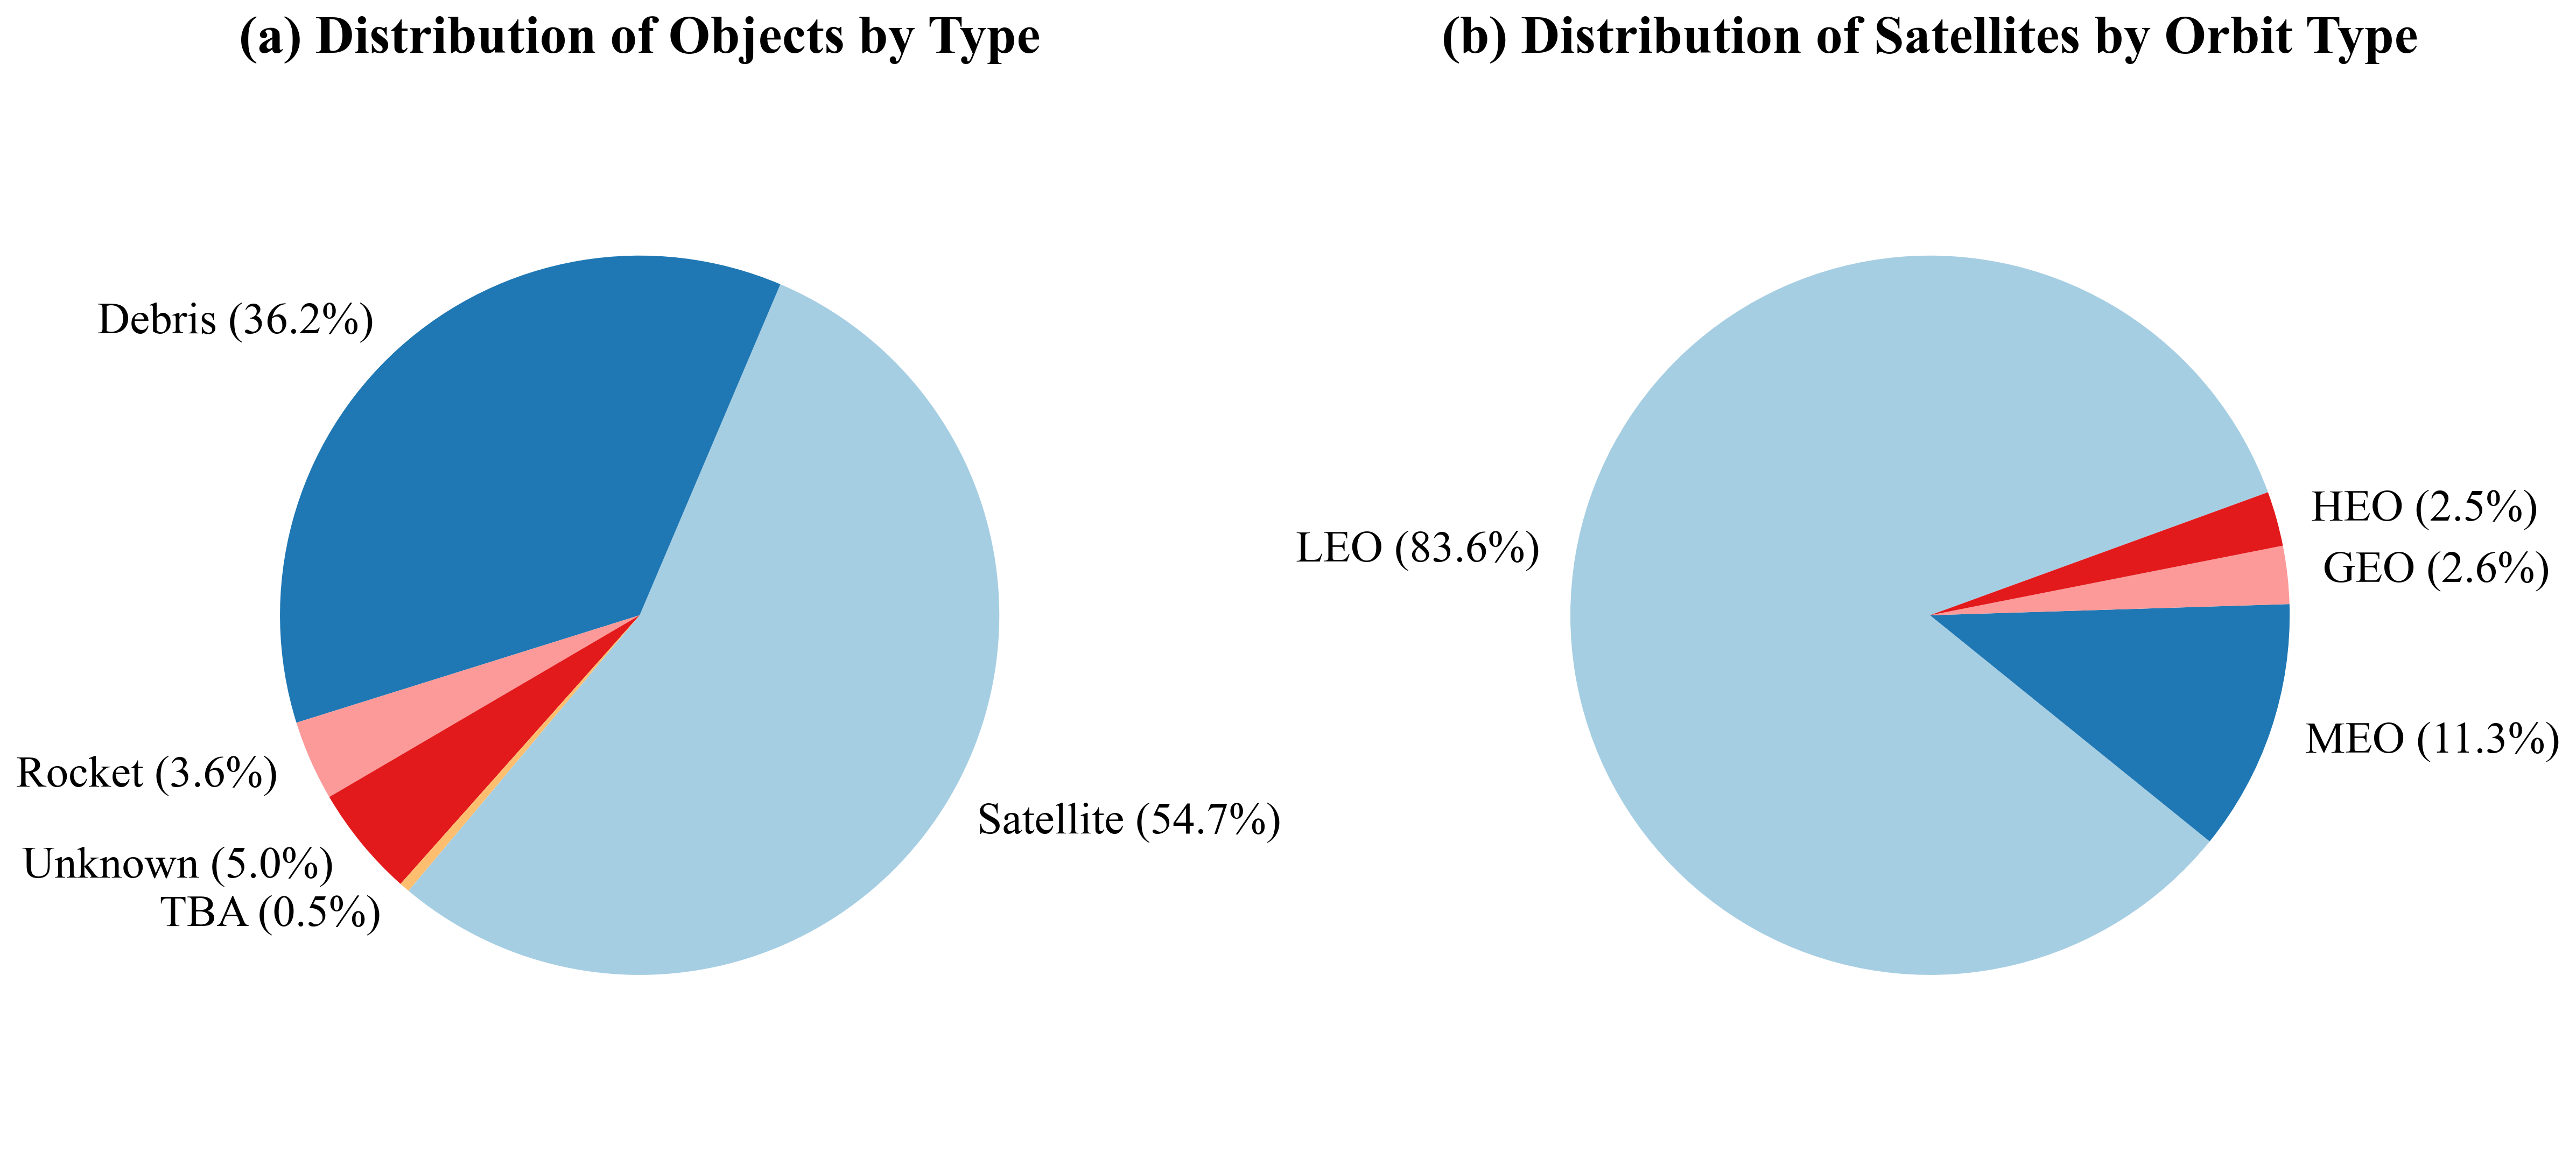

In [ ]:
#Combining the two pie charts above into one for the paper

# Color Scheme
allColors = plt.get_cmap('Paired').colors
customColors = [allColors[i] for i in [0, 1, 4, 5, 6]]

# Create one figure with two side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), dpi=300)

# LEO Object Categories 
totalNumLEO = len(df)
raw_labels1 = ['Satellite', 'Debris', 'Rocket', 'Unknown', 'TBA']
sizes1 = [
    len(df[df['OBJECT_TYPE'] == 'PAYLOAD']) / totalNumLEO * 100,
    len(df[df['OBJECT_TYPE'] == 'DEBRIS']) / totalNumLEO * 100,
    len(df[df['OBJECT_TYPE'] == 'ROCKET BODY']) / totalNumLEO * 100,
    len(df[df['OBJECT_TYPE'] == 'UNKNOWN']) / totalNumLEO * 100,
    len(df[df['OBJECT_TYPE'] == 'TBA']) / totalNumLEO * 100
]
labels1 = [f"{l} ({s:.1f}%)" for l, s in zip(raw_labels1, sizes1)]

ax1.pie(sizes1, labels=labels1, colors=customColors, startangle=230, textprops={'fontsize': 20})
ax1.axis('equal')
# Add the (a) label as a title
ax1.set_title("(a) Distribution of Objects by Type", fontsize=24, pad=10, fontweight='bold')

# Orbital Breakdown
totalNumGlobal = len(LEO) + len(MEO) + len(GEO) + len(HEO) 
raw_labels2 = ['LEO', 'MEO', 'GEO', 'HEO']
sizes2 = [
    len(LEO)/totalNumGlobal*100, 
    len(MEO)/totalNumGlobal*100, 
    len(GEO)/totalNumGlobal*100, 
    len(HEO)/totalNumGlobal*100, 
]
labels2 = [f"{l} ({s:.1f}%)" for l, s in zip(raw_labels2, sizes2)]

ax2.pie(sizes2, labels=labels2, colors=customColors, startangle=20, textprops={'fontsize': 20})
ax2.axis('equal')
# Add the (b) label as a title
ax2.set_title("(b) Distribution of Satellites by Orbit Type", fontsize=24, pad=10, fontweight='bold')

# Clean up gaps and ensure labels fit within the image boundary
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()